Tests out the computer vision side of things, thresholding, dot recognition, color recognition.

In [2]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [3]:
## Input images (Knob 1)
def inputImage(path, pltShow=False):
    img_path = Path("../webcam_storage/" + path + ".jpg")
    image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
    if pltShow:
        print(path)
        plt.imshow(image)
        plt.show()
    return image


# /Users/jdreiling/Desktop/puck/puck/webcam_storage/customs/single_boxes/cm1/setA1.jpg

In [4]:
## Image Preprocessing (Knob 2)
def preprocess(image, pltShow = False):
    imageBlurred = cv.medianBlur(image, 5)
    gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
    if pltShow:
        print("Gray Scale")
        plt.imshow(gray, cmap="gray")
        plt.show()
    return gray

In [5]:
## Image Thresholding (Knob 3)
def threshold(gray, criteriaStr, pltShow = False):
    if criteriaStr == "CV_THRESH_BINARY":
        _, thesholded = cv.threshold(gray, 185, 255, cv.THRESH_BINARY)
    elif criteriaStr == "CV_ADAPT_GAUSS":
         _, thesholded = cv.threshold(gray, 180, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C)
    elif criteriaStr == "CV_ADAPT_MEAN":
         _, thesholded = cv.threshold(gray, 180, 255, cv.ADAPTIVE_THRESH_MEAN_C)
    else: 
        _, thesholded = cv.threshold(gray, 180, 255, cv.THRESH_BINARY)
    if pltShow:
        print("Gray Scale")
        plt.imshow(thesholded, cmap="gray")
        plt.show()
    return thesholded

In [6]:
## Blob Detector Settings (Knobs 4 and 5)
def blobParamFunc(minCircularity, minArea):
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = minCircularity
    params.minArea=minArea
    return params

In [7]:
## Pipeline
def pipeline(imageList, sucessDict, criteria, detector, prints):
    for path in imageList:
        print(path)
        image = inputImage(path,pltShow=prints)
        print(prints)
        gray = preprocess(image,pltShow=prints)
        thresholded = threshold(gray, criteria,prints)
        keypoints = detector.detect(thresholded)
        blank = np.zeros((1, 1))
        blobs = cv.drawKeypoints(image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        if prints == True:
            print("Blobs detected")
            print(len(keypoints))
            plt.imshow(blobs, interpolation="nearest")
            plt.show()
    
        sucessDict.update({path[-1]:[True]}) if len(keypoints) == 4 else sucessDict.update({path[-1]:[False]}) 
    return pd.DataFrame(sucessDict)

In [8]:
### criteria possibilities
criteriaList = ["CV_THRESH_BINARY","CV_ADAPT_GAUSS", "CV_ADAPT_MEAN"]
criteriaList= [criteriaList[0]]

/darks/single_boxes/cm1/setA
/darks/single_boxes/cm1/setA


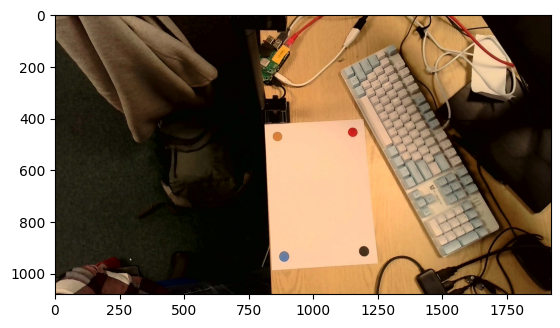

True
Gray Scale


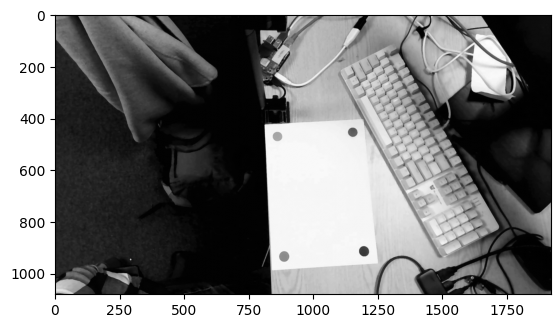

Gray Scale


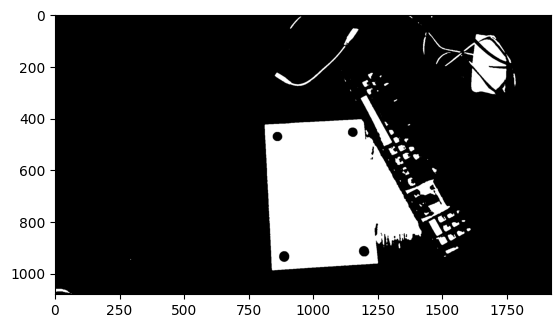

Blobs detected
4


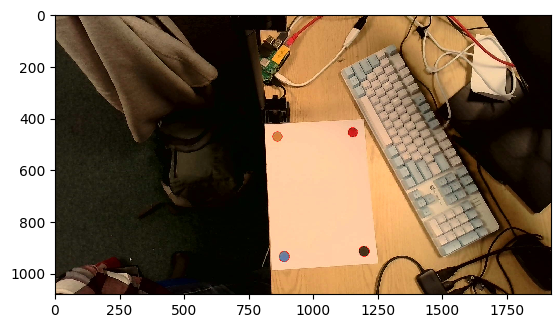

In [11]:
blobParams = blobParamFunc(.1,100)
list = ["A", "B", "C", "D"]
list = list[0]
size = "cm1"
colorPal = "darks"
boxCount = ("single_boxes",4)
paths = ["/" + colorPal + "/" + boxCount[0] + "/" + size + "/set"+ path  for path in list]

for criteria in criteriaList:
    detector = cv.SimpleBlobDetector_create(blobParams)
    sucessDict = {}
    sucessDF = pipeline(paths, sucessDict, criteria, detector, True)
    sucessDF.to_csv("experimental_results/"+ criteria + "_"+ colorPal + "_" + boxCount[0] + "_" + size + ".csv")
